# GW170817: Posterior plot comparison

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import bilby
import pandas as pd
import numpy as np
import seaborn as sns
from bilby.gw.result import CBCResult
import matplotlib.lines as mlines
from kde_contour import Bounded_1d_kde, kdeplot_2d_clevels

/Users/phurailatpamhemantakumar/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Waveforms: TaylorF2Ecck, TaylorF2Ecc 3PN, TaylorF2Ecc 3.5PN

In [2]:
rng = np.random.default_rng(12345)

sns.set_theme(palette='colorblind', font_scale=1.5)

def load_mtot_eta_e0(filename, label, nsamples=None):
    result = bilby.result.read_in_result(filename)
    chirp_mass = result.posterior["chirp_mass"].values
    mass_ratio = result.posterior["mass_ratio"].values
    e0 = result.posterior["eccentricity"].values
    m1 = (chirp_mass*(1+mass_ratio)**(1/5))/mass_ratio**(3/5)
    m2 = chirp_mass*mass_ratio**(2/5)*(1+mass_ratio)**(1/5)
    mtot = m1 + m2
    eta = (m1*m2)/(mtot**2)
    df = pd.DataFrame(np.transpose(np.array([mtot, eta, e0])), columns=['mtot', 'eta', 'e0'])
    if nsamples is not None:
        df = df.sample(nsamples, random_state=rng)
    df[""] = label
    return df

result_files = [
    ("../result_files/TF2Ecck_3PN_bayeswave.hdf5", "Ecck 3PN"),
    ("../result_files/TF2Ecc_3PN_bayeswave.hdf5", "Ecc 3PN"),
    ("../result_files/TF2Ecck_3PN_bayeswave_logprior.hdf5", "Ecck 3PN log-prior"),
    ("../result_files/TF2Ecc_3PN_bayeswave_logprior.hdf5", "Ecc 3PN log-prior"),
]

nsamples = min(len(bilby.result.read_in_result(filename).posterior) for filename, _ in result_files)
result = pd.concat(
    [load_mtot_eta_e0(filename, label, nsamples=nsamples) for filename, label in result_files],
    ignore_index=True,
)

14:50 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
14:50 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
14:50 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
14:50 bilby INFO    : Global meta data was removed from the result object for compatibility

In [3]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'backend': 'Agg',
    'savefig.dpi': 300,
    'grid.alpha': 0.5,
    'path.simplify': True,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    'mathtext.fontset': 'custom',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 1,
    'ytick.minor.width': 1,
    'lines.markeredgewidth': 1,
    'legend.numpoints': 1,
    'legend.frameon': False,
    'legend.handletextpad': 0.3
})

lw = 1
plot_styles = {
    "Ecck 3PN": {"color": "C0", "linestyle": "-"},
    "Ecc 3PN": {"color": "C1", "linestyle": "-"},
    "Ecck 3PN log-prior": {"color": "C0", "linestyle": "--"},
    "Ecc 3PN log-prior": {"color": "C1", "linestyle": "--"},
}

def kdeplot2d(x, y, rng=12345, **kws):
    label = kws.pop('label', None)
    kws.pop('hue_order', None)
    style = plot_styles.get(label, {})
    kws['color'] = style.get('color', kws.pop('color', None))
    kws['linestyles'] = style.get('linestyle', '-')
    kdeplot_2d_clevels(xs=x, ys=y, auto_bound=True, linewidths=lw, rng=rng, **kws)

def kdeplot1d(x, **kws):
    if np.all(x.isna()):
        return
    label = kws.pop('label', None)
    kws.pop('hue_order', None)
    color = kws.pop('color', None)
    style = plot_styles.get(label, {})
    color = style.get('color', color)
    linestyle = style.get('linestyle', '-')
    df = pd.DataFrame({'x': x, 'y': Bounded_1d_kde(x, xlow=min(x), xhigh=max(x), **kws)(x)})
    df = df.sort_values(['x'])
    if linestyle == '-':
        plt.fill_between(df['x'], df['y'], np.zeros(len(x)), color=color, alpha=0.1)
    plt.plot(df['x'], df['y'], color=color, ls=linestyle, lw=lw)
    plt.xlim(df['x'].min(), df['x'].max())
    current_ymax = plt.ylim()[1]
    if current_ymax > df['y'].max()*1.05:
        plt.ylim(0,current_ymax)
    else:
        plt.ylim(0,df['y'].max()*1.05)

vars = ['mtot', 'eta', 'e0']
g = sns.PairGrid(data=result,
                 vars=vars,
                 corner=True, hue="",
                 hue_order=list(plot_styles),
                 diag_sharey=False,
                 layout_pad=0.,
                 height=2.0,
                )
# 1,2,3,4 sigma
g.map_lower(kdeplot2d, levels=[0.864,0.393])
g.map_diag(kdeplot1d)

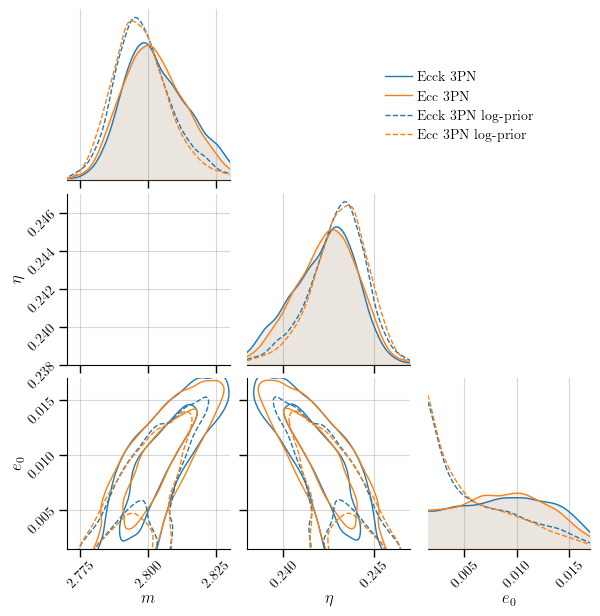

In [4]:
g.axes[2, 2].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 1].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='y', rotation=45, pad=1)
g.axes[1, 0].tick_params(axis='y', rotation=45, pad=1)

g.axes[2, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))  

g.axes[2,0].set_xlabel(r'$m$', labelpad=1, fontsize=12)
g.axes[1,0].set_ylabel(r'$\eta$', labelpad=1, fontsize=12)
g.axes[2,1].set_xlabel(r'$\eta$', labelpad=1, fontsize=12)
g.axes[2,0].set_ylabel(r'$e_0$', labelpad=1, fontsize=12)
g.axes[2,2].set_xlabel(r'$e_0$', labelpad=1, fontsize=12)

min_m = 2.77
max_m = 2.83
min_eta = 0.238
max_eta = 0.247
min_e0 = 0.0015
max_e0 = 0.017
g.axes[2,0].set_xlim(min_m, max_m)
g.axes[2,0].set_ylim(min_e0, max_e0)
g.axes[2,2].set_xlim(min_e0, max_e0)
#
g.axes[2,1].set_xlim(min_eta, max_eta)
g.axes[1,0].set_ylim(min_eta, max_eta)

# add grid
for i in range(3):
    for j in range(3):
        if g.axes[i, j] is not None:
            g.axes[i, j].grid(True, which="both", ls="-", alpha=0.5)

# add legend with line colors
blue_line = mlines.Line2D([], [], color='C0', label='Ecck 3PN', linewidth=1)
orange_line = mlines.Line2D([], [], color='C1', label='Ecc 3PN', linewidth=1)
blue_dashed_line = mlines.Line2D([], [], color='C0', linestyle='--', label='Ecck 3PN log-prior', linewidth=1)
orange_dashed_line = mlines.Line2D([], [], color='C1', linestyle='--', label='Ecc 3PN log-prior', linewidth=1)
handles = [blue_line, orange_line, blue_dashed_line, orange_dashed_line]
labels = [h.get_label() for h in handles] 
g.fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0., 0.9, 0.9, .0), ncol=1) # Adjust loc and ncol as needed

g.savefig("GW170817_mtot_eta_e0.pdf", bbox_inches="tight", dpi=300)
plt.show()

* You don't see the $\eta$ vs $m$ contour because the KDE is too narrow.

* The contour plots of $e_0$ vs $m$ and $e_0$ vs $\eta$ are later crop out using `Affinity Designer` software and create the Figure 5.